In [2]:
# using HDF5
using PyPlot
using ProgressBars
using JLD2
using Images
using Statistics
# using Interpolations

In [3]:
function load_crop_imgs(filenames, pathdir, x_crop, y_crop)
    imgs_atoms, imgs_bkg, imgs_dark, intensities = [], [], [], []

    for filename in filenames
        filename = pathdir*"/"*filename
        h5open(filename, "r") do file
            img_atoms = crop_img(convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/atoms"])), x_crop, y_crop)
            img_bkg = crop_img(convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/background"])), x_crop, y_crop)
            img_dark = crop_img(convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/dark"])), x_crop, y_crop)
            push!(imgs_atoms, img_atoms), push!(imgs_bkg, img_bkg), push!(imgs_dark, img_dark), push!(intensities, read_attribute(file["globals"], "vert_abs_img_amp_high"))
        end
    end
    return imgs_atoms, imgs_bkg, imgs_dark, intensities
end

function crop_img(img, x_crop, y_crop)
    return img[y_crop, x_crop]
end

function compute_OD_high_low_intensity(imgs_atoms, imgs_bkg, imgs_dark, sat, t_exp)
    ODs = zeros(size(imgs_atoms))
    for i in 1:size(imgs_atoms)[1]
        for j = 1:size(imgs_atoms)[2]
            OD = (imgs_atoms[i, j, :, :] .- imgs_dark[i, j, :, :]) ./ (imgs_bkg[i, j, :, :] .- imgs_dark[i, j, :, :])

            OD[OD .<= 0] .= NaN # Values where dark is brighter than laser/atoms are not taken into account
            OD .= -log10.(OD)
            OD[isnan.(OD)] .= 0 # Map Nan values to 0
            OD[OD .== -Inf] .= 0 # Some values are send to -Inf

            # For high intensity, modified OD formula
            if sat[i] >= 1
                OD .+= (imgs_bkg[i, j, :, :] .- imgs_atoms[i, j, :, :]) / (7000*t_exp/5e-6)
            end
            ODs[i, j, :, :] .= OD
        end
    end
    return ODs
end

compute_OD_high_low_intensity (generic function with 1 method)

In [ ]:
# pathdir = "Y:/TwoDGas/2026/01/19/0047"
pathdir = "Y:/TwoDGas/2026/02/06/0000"
# Sat = [0.004, 0.4, 1.7, 4.7, 10, 16.5, 23, 28.5, 33, 37.5] # Estimated saturation parameter "Y:/TwoDGas/2026/01/19"
# I_set_value = [0.1:0.1:1;] # "Y:/TwoDGas/2026/01/19"
# I_set_value = [0.1:0.05:1;] # "Y:/StructuralPhaseTransition/2026/02/02/0000"
# I_set_value = [0.1:0.05:1;] # "Y:/StructuralPhaseTransition/2026/02/02/0000"
τ_exp = 5e-6 # In s
# x_crop = [1100:1700;] # "Y:/TwoDGas/2026/01/19"
# y_crop = [1750:2450;];
x_crop = [1300:1700;] # "Y:/StructuralPhaseTransition/2026/02/02"
y_crop = [1750:2150;];

### Load and crop the images

In [ ]:
if !isdir("Saved_exp_data")
    mkdir("Saved_exp_data")
end

In [ ]:
files_path = readdir(pathdir)
Imgs_atoms_crop, Imgs_bkg_crop, Imgs_dark_crop, Intensities = load_crop_imgs(files_path, pathdir, x_crop, y_crop)
idx_sorting_intensities = sortperm(Intensities)
Imgs_atoms_crop, Imgs_bkg_crop, Imgs_dark_crop, Intensities = Imgs_atoms_crop[idx_sorting_intensities], Imgs_bkg_crop[idx_sorting_intensities], Imgs_dark_crop[idx_sorting_intensities], Intensities[idx_sorting_intensities];

### Interpolate values of Sat if we only have the $I_{set}$ values

In [ ]:
Sat_old = [0.004, 0.4, 1.7, 4.7, 10, 16.5, 23, 28.5, 33, 37.5] # "Y:/TwoDGas/2026/01/19"
I_set_value_old  = [0.1:0.1:1;] # "Y:/TwoDGas/2026/01/19"

itp = interpolate((I_set_value_old,), Sat_old, Gridded(Linear()))
Sat = itp.(Intensities)

close("all")
plot(I_set_value_old, Sat_old, marker="o", label="Exp pts")
plot(Intensities, Sat, marker="o", markerfacecolor="none", label="Interpolation")
xlabel(L"$I_{set}$ (A.U)")
ylabel("Sat")
legend()
# pygui(true); show();
pygui(false);

In [ ]:
Sat = unique(Sat); # Remove duplciates

### Reorganize the data per datasets

In [ ]:
Imgs_atoms_crop_ds, Imgs_bkg_crop_ds, Imgs_dark_crop_ds = zeros((length(Sat), Integer(length(files_path)/length(Sat)), length(y_crop), length(x_crop))), zeros((length(Sat), Integer(length(files_path)/length(Sat)), length(y_crop), length(x_crop))), zeros((length(Sat), Integer(length(files_path)/length(Sat)), length(y_crop), length(x_crop)))

for i in 1:length(Imgs_atoms_crop)
        idx_line = findfirst(==(Intensities[i]), unique(Intensities))
        idx_row = floor(Int64, ((i-1)%(length(Sat))+1))
        Imgs_atoms_crop_ds[idx_line, idx_row, :, :] .= Imgs_atoms_crop[i]
        Imgs_bkg_crop_ds[idx_line, idx_row, :, :] .= Imgs_bkg_crop[i]
        Imgs_dark_crop_ds[idx_line, idx_row, :, :] .= Imgs_dark_crop[i]
end

In [ ]:
@save "Saved_exp_data/Imgs_croped_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Sat τ_exp Imgs_atoms_crop_ds Imgs_bkg_crop_ds Imgs_dark_crop_ds

In [7]:
@load "Saved_exp_data/Imgs_croped_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Sat τ_exp Imgs_atoms_crop_ds Imgs_bkg_crop_ds Imgs_dark_crop_ds

5-element Vector{Symbol}:
 :Sat
 :τ_exp
 :Imgs_atoms_crop_ds
 :Imgs_bkg_crop_ds
 :Imgs_dark_crop_ds

### Compute the ODs

In [8]:
ODs_dataset = compute_OD_high_low_intensity(Imgs_atoms_crop_ds, Imgs_bkg_crop_ds, Imgs_dark_crop_ds, Sat, τ_exp);

In [9]:
@save "Saved_exp_data/ODs_crop_"*join(split(pathdir, "/")[3:end], "_")*".jld2" ODs_dataset

### Plot to check

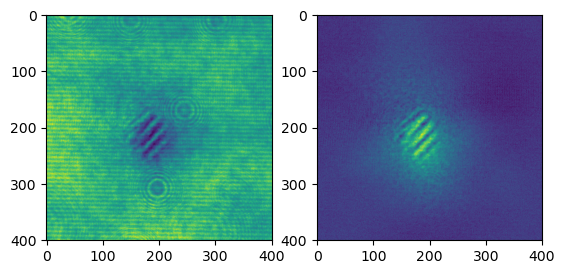

false

In [10]:
i, j = 19, 5

close("all")
fig, axs = subplots(1, 2)
axs[1].imshow(Imgs_atoms_crop_ds[i, j, :, :])
axs[2].imshow(ODs_dataset[i, j, :, :])
pygui(false)

# Save the ODs and negative ODs

In [11]:
if !isdir("Images")
    mkdir("Images")
end
if !isdir("Images/"*join(split(pathdir, "/")[3:end], "_"))
    mkdir("Images/"*join(split(pathdir, "/")[3:end], "_"))
end
if !isdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/ODs")
    mkdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/ODs")
end
if !isdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Negative_ODs")
    mkdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Negative_ODs")
end

"Images/2026_02_06_0000/Negative_ODs"

In [12]:
close("all")
fig, axs = subplots()

for i in ProgressBar(1:size(ODs_dataset)[1])
    if !isdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/ODs/$(Sat[i])")
        mkdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/ODs/$(Sat[i])")
    end
    for j = 1:size(ODs_dataset)[2]
        img = axs.imshow(ODs_dataset[i, j, :, :], cmap="plasma") #, aspect="auto"
        cb = colorbar(img)
        savefig("Images/"*join(split(pathdir, "/")[3:end], "_")*"/ODs/$(Sat[i])/$(j-1).png")
        cb.remove()
        axs.clear()
    end
end
close("all")

0.0%┣                                              ┫ 0/19 [00:04<-1:-20, -4s/it]
5.3%┣██▎                                        ┫ 1/19 [00:11<Inf:Inf, InfGs/it]
10.5%┣████▉                                         ┫ 2/19 [00:15<04:23, 15s/it]
15.8%┣███████▎                                      ┫ 3/19 [00:20<02:43, 10s/it]
21.1%┣██████████                                     ┫ 4/19 [00:27<02:15, 9s/it]
26.3%┣████████████▍                                  ┫ 5/19 [00:31<01:48, 8s/it]
31.6%┣██████████████▉                                ┫ 6/19 [00:35<01:31, 7s/it]
36.8%┣█████████████████▎                             ┫ 7/19 [00:39<01:19, 7s/it]
42.1%┣███████████████████▉                           ┫ 8/19 [00:43<01:08, 6s/it]
47.4%┣██████████████████████▎                        ┫ 9/19 [00:47<00:59, 6s/it]
52.6%┣████████████████████████▏                     ┫ 10/19 [00:52<00:52, 6s/it]
57.9%┣██████████████████████████▋                   ┫ 11/19 [00:56<00:45, 6s/it]
63.2%┣██████████████████████

In [13]:
close("all")
fig, axs = subplots()

for i in ProgressBar(1:size(ODs_dataset)[1])
    if !isdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Negative_ODs/$(Sat[i])")
        mkdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Negative_ODs/$(Sat[i])")
    end
    for j = 1:size(ODs_dataset)[2]
        img = axs.imshow(ODs_dataset[i, j, :, :], cmap="bone", vmin=-0.2, vmax=0) #, aspect="auto"
        cb = colorbar(img)
        savefig("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Negative_ODs/$(Sat[i])/$(j-1).png")
        cb.remove()
        axs.clear()
    end
end
close("all")

0.0%┣                                               ┫ 0/19 [00:00<00:00, -0s/it]
5.3%┣██▎                                        ┫ 1/19 [00:04<Inf:Inf, InfGs/it]
10.5%┣█████                                          ┫ 2/19 [00:08<02:18, 8s/it]
15.8%┣███████▍                                       ┫ 3/19 [00:12<01:34, 6s/it]
21.1%┣██████████                                     ┫ 4/19 [00:15<01:17, 5s/it]
26.3%┣████████████▍                                  ┫ 5/19 [00:19<01:06, 5s/it]
31.6%┣██████████████▉                                ┫ 6/19 [00:22<00:58, 4s/it]
36.8%┣█████████████████▎                             ┫ 7/19 [00:26<00:52, 4s/it]
42.1%┣███████████████████▉                           ┫ 8/19 [00:30<00:47, 4s/it]
47.4%┣██████████████████████▎                        ┫ 9/19 [00:33<00:42, 4s/it]
52.6%┣████████████████████████▏                     ┫ 10/19 [00:37<00:37, 4s/it]
57.9%┣██████████████████████████▋                   ┫ 11/19 [00:40<00:32, 4s/it]
63.2%┣██████████████████████

# Brouillons

<!-- Imgs_atoms_crop_ds, Imgs_bkg_crop_ds, Imgs_dark_crop_ds = zeros((length(Sat), Integer(length(files_path)/length(Sat)), length(y_crop), length(x_crop))), zeros((length(Sat), Integer(length(files_path)/length(Sat)), length(y_crop), length(x_crop))), zeros((length(Sat), Integer(length(files_path)/length(Sat)), length(y_crop), length(x_crop)))

for i in 1:length(Imgs_atoms_crop)
        idx_line = findfirst(==(Intensities[i]), unique(Intensities))
        println(idx_line)
        idx_row = floor(Int64, ((i-1)/(length(Sat))+1))
        println(idx_row)
        Imgs_atoms_crop_ds[idx_line, idx_row, :, :] .= Imgs_atoms_crop[i]
        Imgs_bkg_crop_ds[idx_line, idx_row, :, :] .= Imgs_bkg_crop[i]
        Imgs_dark_crop_ds[idx_line, idx_row, :, :] .= Imgs_dark_crop[i]
end -->